# Statistická analýza, příprava dat

## Portland Housing Prices/Sales Jul 2020 - Jul 2021
- https://www.kaggle.com/datasets/threnjen/portland-housing-prices-sales-jul-2020-jul-2021
- 348 columns
- 25681 records

Pro tento příklad budeme používat podmnožinu s tohoto souboru.
!!! Vytvořený subset nemusí statisticky odpovídat původnímu souboru

## Sub dataset
- Data  = struktura s vyplněnými daty
- m 	= počet řádků = 100
- x’s = vstupní proměnná / features
- y’s = výstupní promměná / target
- (x, y) = jeden řádek z training dataset
- x(2) = (4, 5, 3374, 85)
- y(2) = 1 050 000

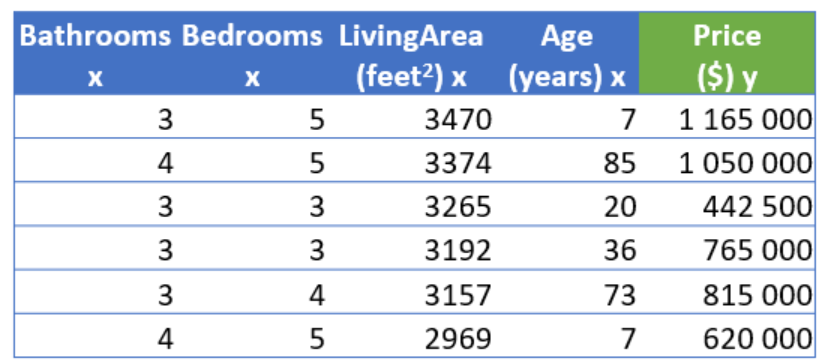

# Úkol
- Vytvořte regresní lineání model z parametrů, které jste vybrali minulé cvičení
- Data před zpracováním standardizujte
- Model vytvořte ručně
- Model vytvořte pomocí scikit-learn

# Načtení dat

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv ("../dataset/portland_filtered.csv",  sep=';')

# Lineání model bez pomocí knihoven
- Vytvořte si ručně model lineární regrese bez pomoci externích knihoven
- Vypište jeho parametry
- Vypiše jeho skóre pro trénovací a validační data
- Vykreslete graf historie učení
- Vizualizujte model

In [4]:
data=data.dropna()

In [ ]:
X = data[['livingArea']].values  
Y = data['price'].values  

In [ ]:
def normalize_data(X, Y):
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    Y_mean = np.mean(Y)
    Y_std = np.std(Y)
    
    X_normalized = (X - X_mean) / X_std
    Y_normalized = (Y - Y_mean) / Y_std
    
    return X_normalized, Y_normalized, X_mean, X_std, Y_mean, Y_std

X_normalized, Y_normalized, X_mean, X_std, Y_mean, Y_std = normalize_data(X, Y)

In [ ]:
def initialize(n_features):
    bias = 0
    weights = np.zeros(n_features)
    return bias, weights

n_features = X.shape[1]  # Should be 1
bias, weights = initialize(n_features)

In [ ]:
def predict(X, bias, weights):
    return bias + np.dot(X, weights)

Y_pred = predict(X_normalized, bias, weights)

In [ ]:
def compute_cost(Y_true, Y_pred):
    m = len(Y_true)
    cost = (1/(2*m)) * np.sum((Y_true - Y_pred) ** 2)
    return cost

initial_cost = compute_cost(Y_normalized, Y_pred)
print(f"Initial cost (MSE): {initial_cost}")

Initial cost (MSE): 143475677095.1276


In [ ]:
def gradient_descent(X, Y, bias, weights, learning_rate, num_iterations):
    m = len(Y)
    cost_history = []
    
    for i in range(num_iterations):
        Y_pred = predict(X, bias, weights)

        bias_gradient = (1/m) * np.sum(Y_pred - Y)
        weights_gradient = (1/m) * np.dot(X.T, (Y_pred - Y))

        bias -= learning_rate * bias_gradient
        weights -= learning_rate * weights_gradient

        cost = compute_cost(Y, Y_pred)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
    
    return bias, weights, cost_history

learning_rate = 0.01
num_iterations = 1000
bias, weights, cost_history = gradient_descent(X_normalized, Y_normalized, bias, weights, learning_rate, num_iterations)

Iteration 0, Cost: 0.5
Iteration 100, Cost: 0.2499111273440568
Iteration 200, Cost: 0.2164043015000192
Iteration 300, Cost: 0.2119150678679127
Iteration 400, Cost: 0.2113136018055216
Iteration 500, Cost: 0.21123301757804439
Iteration 600, Cost: 0.2112222209294483
Iteration 700, Cost: 0.21122077439797984
Iteration 800, Cost: 0.211220580592164
Iteration 900, Cost: 0.21122055462612388


In [37]:
print("Final Model Parameters:")
print(f"Bias (intercept): {bias}")
print(f"Weight for livingArea: {weights[0]}")

Final Model Parameters:
Bias (intercept): 1.3533618670180594e-17
Weight for livingArea: 0.7599401502633134


In [ ]:
# - Vypiše jeho skóre pro trénovací a validační data
def r2_score(Y_true, Y_pred):
    mean_y = np.mean(Y_true)
    ss_tot = np.sum((Y_true - mean_y) ** 2)
    ss_res = np.sum((Y_true - Y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

Y_pred_normalized = predict(X_normalized, bias, weights)

Y_pred = Y_pred_normalized * Y_std + Y_mean

train_r2 = r2_score(Y, Y_pred)
print(f"Training R² Score: {train_r2}")

Training R² Score: 0.5775588977055954


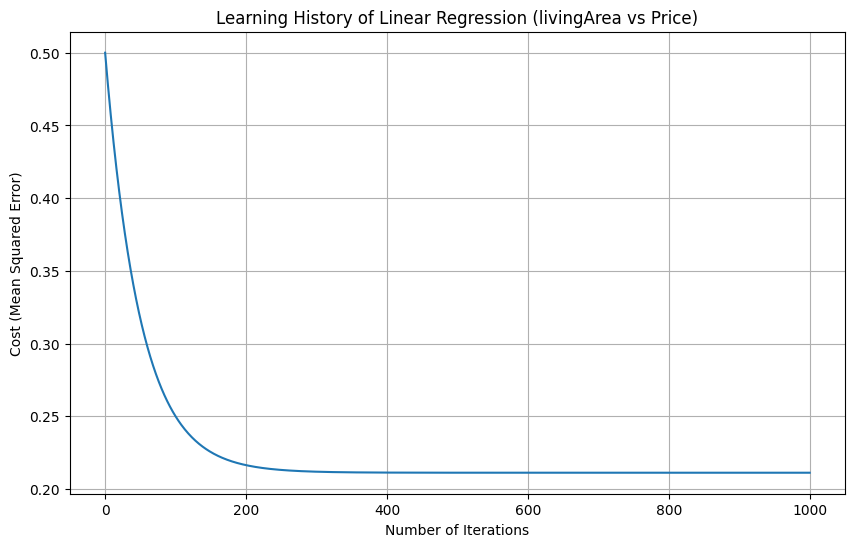

In [ ]:
# - Vykreslete graf historie učení
plt.figure(figsize=(10, 6))
plt.plot(range(num_iterations), cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (Mean Squared Error)")
plt.title("Learning History of Linear Regression (livingArea vs Price)")
plt.grid(True)
plt.show()

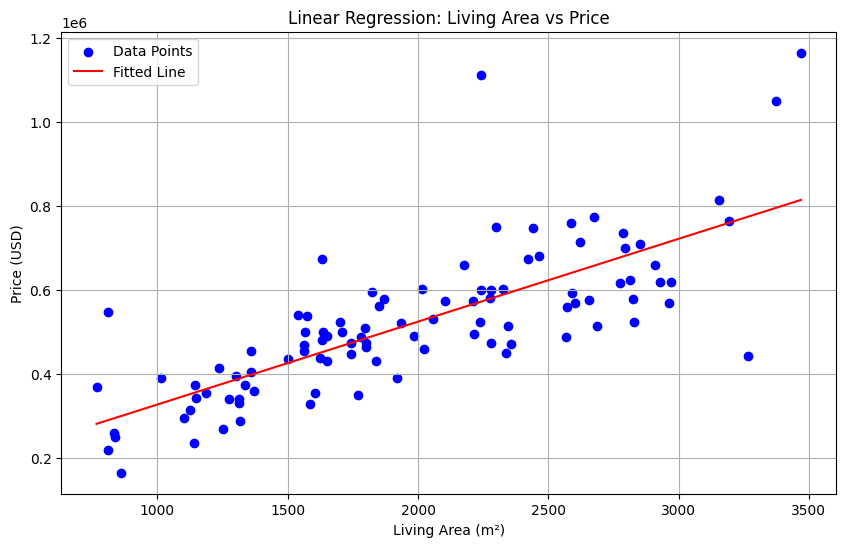

In [ ]:
# - Vizualizujte model
X1 = X[:, 0]  
Y = Y  

plt.figure(figsize=(10, 6))
plt.scatter(X1, Y, color='blue', label='Data Points')

X_line = np.linspace(min(X1), max(X1), 100).reshape(-1, 1)
X_line_normalized = (X_line - X_mean) / X_std
Y_line_normalized = predict(X_line_normalized, bias, weights)
Y_line = Y_line_normalized * Y_std + Y_mean

plt.plot(X_line, Y_line, color='red', label='Fitted Line')

plt.xlabel('Living Area (m²)')
plt.ylabel('Price (USD)')
plt.title('Linear Regression: Living Area vs Price')
plt.legend()
plt.grid(True)
plt.show()

# Linearní modelu pomocí scikit-learn
- Vytvořte si ručně model lineární regrese bez pomoci externích knihoven
- Vypište jeho parametry
- Vypiše jeho skóre pro trénovací a validační data
- Vykreslete graf historie učení
- Vizualizujte model

In [ ]:
# - Vytvořte si ručně model lineární regrese bez pomoci externích knihoven
from sklearn.linear_model import LinearRegression

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.3, random_state=42)
lin_model = LinearRegression()

In [ ]:
lin_model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# - Vypište jeho parametry
print("Model Parameters:")
print(f"Bias (intercept): {lin_model.intercept_}")
print(f"Weight for livingArea: {lin_model.coef_[0]}")

Model Parameters:
Bias (intercept): 169662.64990177134
Weight for livingArea: 178.32708749062937


In [ ]:
# - Vypiše jeho skóre pro trénovací a validační data
Y_train_pred = lin_model.predict(X_train)
train_r2 = r2_score(Y_train, Y_train_pred)
print(f"Training R² Score: {train_r2}")

Y_val_pred = lin_model.predict(X_val)
val_r2 = r2_score(Y_val, Y_val_pred)
print(f"Validation R² Score: {val_r2}")

Training R² Score: 0.5105424718714492
Validation R² Score: 0.6838208424364691


Iteration 0, Cost: 0.5
Iteration 100, Cost: 0.2499111273440568
Iteration 200, Cost: 0.2164043015000192
Iteration 300, Cost: 0.2119150678679127
Iteration 400, Cost: 0.2113136018055216
Iteration 500, Cost: 0.21123301757804439
Iteration 600, Cost: 0.2112222209294483
Iteration 700, Cost: 0.21122077439797984
Iteration 800, Cost: 0.211220580592164
Iteration 900, Cost: 0.21122055462612388


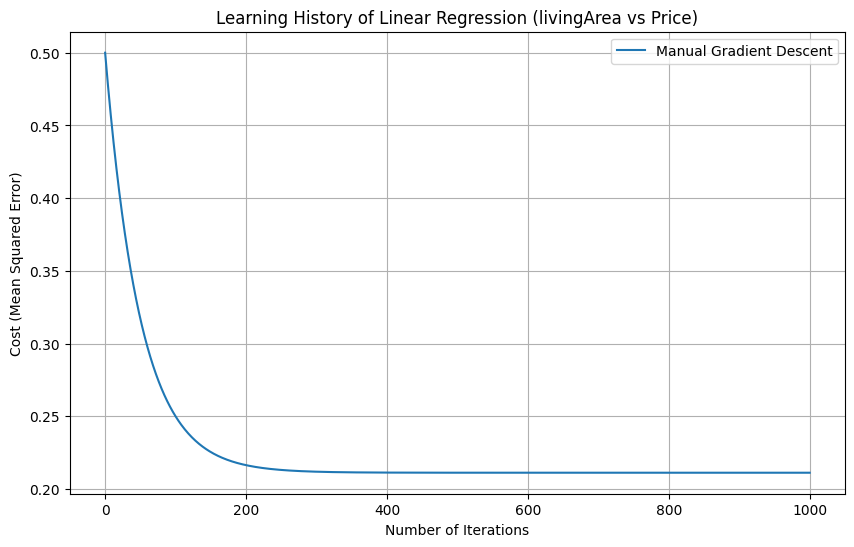

In [ ]:
# - Vykreslete graf historie učení
def normalize_data(X, Y):
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    Y_mean = np.mean(Y)
    Y_std = np.std(Y)
    
    X_normalized = (X - X_mean) / X_std
    Y_normalized = (Y - Y_mean) / Y_std
    
    return X_normalized, Y_normalized, X_mean, X_std, Y_mean, Y_std

X_normalized, Y_normalized, X_mean, X_std, Y_mean, Y_std = normalize_data(X, Y)

def initialize(n_features):
    bias = 0
    weights = np.zeros(n_features)
    return bias, weights

def predict(X, bias, weights):
    return bias + np.dot(X, weights)

def compute_cost(Y_true, Y_pred):
    m = len(Y_true)
    cost = (1/(2*m)) * np.sum((Y_true - Y_pred) ** 2)
    return cost

def gradient_descent(X, Y, bias, weights, learning_rate, num_iterations):
    m = len(Y)
    cost_history = []
    
    for i in range(num_iterations):
        Y_pred = predict(X, bias, weights)
        bias_gradient = (1/m) * np.sum(Y_pred - Y)
        weights_gradient = (1/m) * np.dot(X.T, (Y_pred - Y))
        bias -= learning_rate * bias_gradient
        weights -= learning_rate * weights_gradient
        cost = compute_cost(Y, Y_pred)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
    
    return bias, weights, cost_history

n_features = X_normalized.shape[1]
bias, weights = initialize(n_features)
learning_rate = 0.01
num_iterations = 1000
bias, weights, cost_history = gradient_descent(X_normalized, Y_normalized, bias, weights, learning_rate, num_iterations)

plt.figure(figsize=(10, 6))
plt.plot(range(num_iterations), cost_history, label='Manual Gradient Descent')
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (Mean Squared Error)")
plt.title("Learning History of Linear Regression (livingArea vs Price)")
plt.grid(True)
plt.legend()
plt.show()

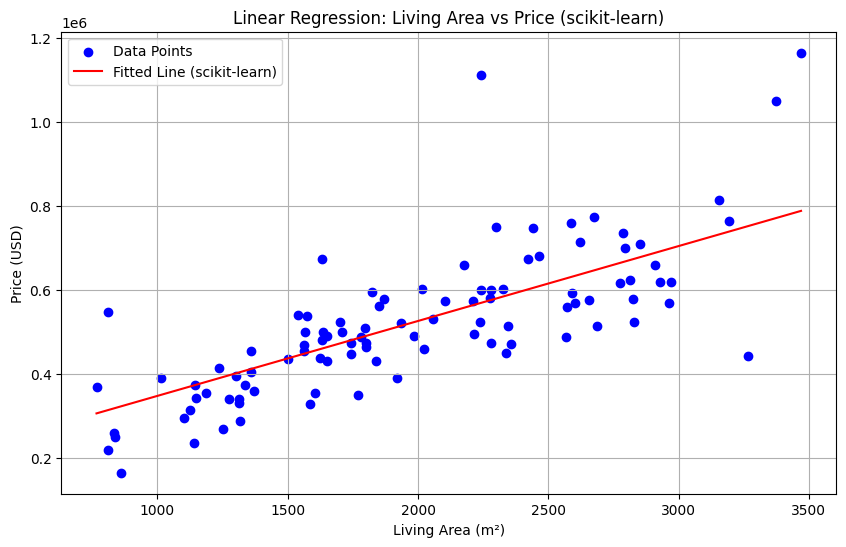

In [ ]:
# - Vizualizujte model
X_full = X[:, 0]  
Y_full = Y 

plt.figure(figsize=(10, 6))
plt.scatter(X_full, Y_full, color='blue', label='Data Points')

X_line = np.linspace(min(X_full), max(X_full), 100).reshape(-1, 1)
Y_line = lin_model.predict(X_line)

plt.plot(X_line, Y_line, color='red', label='Fitted Line (scikit-learn)')

plt.xlabel('Living Area (m²)')
plt.ylabel('Price (USD)')
plt.title('Linear Regression: Living Area vs Price (scikit-learn)')
plt.legend()
plt.grid(True)
plt.show()